# Question 1 — Emergency Logistics after Climate Events

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src

## 1. Dataset (Part A)

The dataset is generated once from `SEED = 1` (`src/data_generator.py`) and written to
`data/problema1.csv` / `data/problema1_edges.csv`. This notebook reads it back with
`data_loader.load_instance`, exactly as the graded run will.

In [2]:
import matplotlib.pyplot as plt

from src.data_generator import CAPACITY_FRACTION, N_SITES, SEED
from src.data_loader import load_instance
from src.dynamic_programming import solve_dp
from src.estruturas import Depot, Edge, Instance, Site
from src.greedy import solve_greedy
from src.measurements import peak_memory_bytes, sweep_dp_time_by_n, sweep_greedy_time_by_n
from src.objective import LAMBDA_DISTANCE_PRICE, build_order, calibrate_lambda
from src.plots import (
    demo_capacity_for_figure_3,
    demo_subset_for_figure_3,
    plot_dp_table,
    plot_instance_graph,
    plot_solution,
    plot_time_growth,
)
from src.shortest_paths import dijkstra, distance_matrix

DATA_DIR = REPO_ROOT / "data"
instance = load_instance(DATA_DIR / "problema1.csv", DATA_DIR / "problema1_edges.csv")

n_available = sum(1 for edge in instance.edges if edge.available)
n_blocked = sum(1 for edge in instance.edges if not edge.available)
print(f"SEED = {SEED}")
print(f"Depot: {instance.depot.name} at ({instance.depot.x}, {instance.depot.y})")
print(f"{len(instance.sites)} candidate sites (N_SITES = {N_SITES})")
print(f"{n_available} available roads, {n_blocked} blocked roads, "
      f"{n_available + n_blocked} total candidate roads")

SEED = 1
Depot: Distribution Center at (50, 50)
20 candidate sites (N_SITES = 20)
38 available roads, 8 blocked roads, 46 total candidate roads


### Figure 1 — Service network

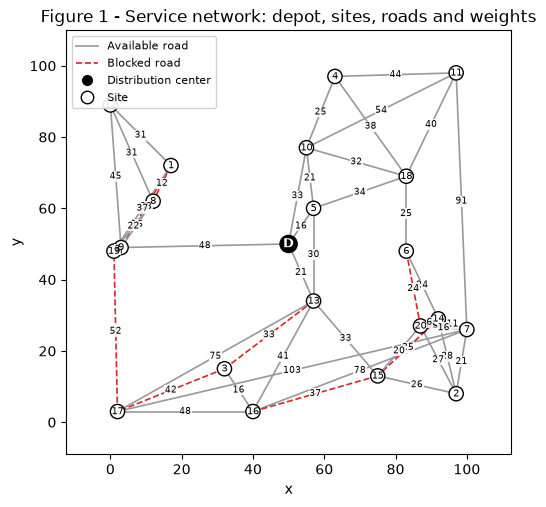

In [3]:
fig1 = plot_instance_graph(instance)
plt.show()

## 2. Shortest paths and the canonical order pi (Decision D9)

Distances come from our own Dijkstra (`shortest_paths.dijkstra`), over available roads only
(Decision D6). `pi` is the pre-order DFS of the resulting shortest-path tree
(`objective.build_order`); it is used by both solvers below so that Greedy and DP optimize the
exact same route-length model.

In [4]:
graph = instance.graph()
depot_id = instance.depot.node_id
distance_from_depot, parent = dijkstra(graph, depot_id)
pi_order = build_order(distance_from_depot, parent, depot_id)
distance = distance_matrix(graph, [depot_id, *pi_order])

print(f"pi order ({len(pi_order)} candidate sites): {pi_order}")

benefits = [site.effective_benefit for site in instance.sites]
distances_from_depot = [distance_from_depot[site.node_id] for site in instance.sites]
recalibrated_lambda = calibrate_lambda(benefits, distances_from_depot)
print(f"lambda (Decision D11, median(effective_benefit)/median(distance from depot)): "
      f"{recalibrated_lambda}")
assert recalibrated_lambda == LAMBDA_DISTANCE_PRICE, "LAMBDA_DISTANCE_PRICE must match D11's rule"
print(f"LAMBDA_DISTANCE_PRICE (fixed constant, objective.py) = {LAMBDA_DISTANCE_PRICE}")

pi order (20 candidate sites): [5, 18, 6, 13, 15, 20, 14, 7, 2, 16, 3, 17, 10, 4, 11, 9, 19, 1, 8, 12]
lambda (Decision D11, median(effective_benefit)/median(distance from depot)): 21
LAMBDA_DISTANCE_PRICE (fixed constant, objective.py) = 21


## 3. Capacity

Capacity is a parameter of the experiment, not stored in the data (Decision D14). The notebook's
default is `floor(CAPACITY_FRACTION * total_load)`; it can be changed freely (see Section 8).

In [5]:
total_load = sum(site.load for site in instance.sites)
capacity = int(CAPACITY_FRACTION * total_load)
print(f"Total load over all candidate sites = {total_load}")
print(f"CAPACITY_FRACTION = {CAPACITY_FRACTION} -> default capacity = {capacity}")

Total load over all candidate sites = 1662
CAPACITY_FRACTION = 0.35 -> default capacity = 581


## 4. Greedy solution (Part B, Decision D12)

At each step, Greedy picks the not-yet-served site with the highest marginal-benefit density
`delta_J_i(S) / load_i` among sites that still fit the remaining capacity, stopping when no site
has positive marginal gain.

In [6]:
greedy_solution = solve_greedy(instance, capacity=capacity, pi_order=pi_order, distance=distance)

print(f"Greedy plan: {len(greedy_solution.selected_sites)} sites served")
print(f"  selected_sites (pi order) = {greedy_solution.selected_sites}")
print(f"  total_benefit = {greedy_solution.total_benefit}")
print(f"  total_load    = {greedy_solution.total_load} / {capacity}")
print(f"  route_length  = {greedy_solution.route_length}")
print(f"  J(S)          = {greedy_solution.objective_value}")

Greedy plan: 8 sites served
  selected_sites (pi order) = (5, 18, 6, 13, 15, 20, 7, 11)
  total_benefit = 15565
  total_load    = 564 / 581
  route_length  = 318
  J(S)          = 8887


## 5. Dynamic Programming solution (Part C, Section 4)

Bottom-up DP over states `(last site in pi order, load)`; see `src/dynamic_programming.py`'s
module docstring and `docs/analise_complexidade.md` for the full state/decision/base
case/recurrence/reconstruction explanation.

In [7]:
dp_solution, dp_table = solve_dp(instance, capacity=capacity, pi_order=pi_order, distance=distance)

print(f"DP plan: {len(dp_solution.selected_sites)} sites served")
print(f"  selected_sites (pi order) = {dp_solution.selected_sites}")
print(f"  total_benefit = {dp_solution.total_benefit}")
print(f"  total_load    = {dp_solution.total_load} / {capacity}")
print(f"  route_length  = {dp_solution.route_length}")
print(f"  J(S)          = {dp_solution.objective_value}")
print(f"  dp table shape = {len(dp_table)} sites x {len(dp_table[0])} loads")

DP plan: 7 sites served
  selected_sites (pi order) = (5, 18, 6, 13, 9, 8, 12)
  total_benefit = 17439
  total_load    = 580 / 581
  route_length  = 274
  J(S)          = 11685
  dp table shape = 20 sites x 582 loads


### Figure 2 — Service plan (DP solution)

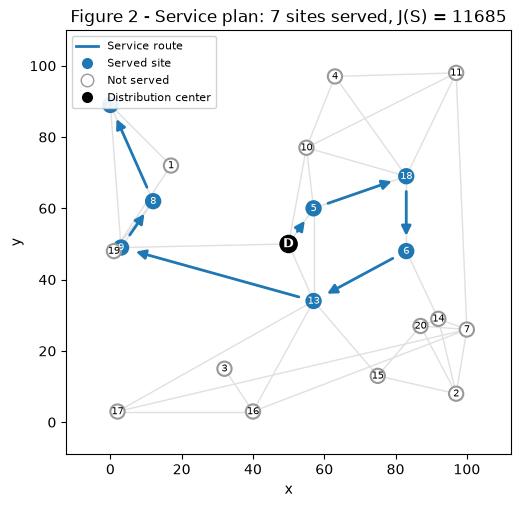

In [8]:
fig2 = plot_solution(instance, dp_solution)
plt.show()

## 6. Greedy x DP comparison and counterexample (Part D, Decision D7)

Both solvers are run on the exact same instance, `pi_order`, `distance` matrix and
`lambda_price`, so any gap between them comes only from the strategy (Decision D4).

In [9]:
gap = dp_solution.objective_value - greedy_solution.objective_value
print(f"On the real seed-1 dataset: DP J(S) = {dp_solution.objective_value}, "
      f"Greedy J(S) = {greedy_solution.objective_value}, gap = {gap}")
if gap > 0:
    print("DP strictly outperforms Greedy here: the myopic density rule leaves capacity "
          "unused that a different combination fills with more total benefit.")
else:
    print("Greedy matches the DP optimum on this run.")

On the real seed-1 dataset: DP J(S) = 11685, Greedy J(S) = 8887, gap = 2798
DP strictly outperforms Greedy here: the myopic density rule leaves capacity unused that a different combination fills with more total benefit.


### A hand-built counterexample

A small instance where Greedy's density rule is provably not optimal, worked out by hand
(see `tests/test_questao1.py::_counterexample_instance` for the same numbers as a stored test):

Depot plus 3 sites, all pairwise distances equal to 1 (so route cost only ever adds +1 per hop,
isolating the knapsack effect). Capacity 10:

* Site 1: load 6, benefit 60 -> density 10.0 (the single best density).
* Site 2: load 5, benefit 45 -> density 9.0.
* Site 3: load 5, benefit 45 -> density 9.0.

Greedy takes site 1 first (highest density); the remaining capacity (4) then fits neither site 2
nor site 3, so Greedy stops with only site 1. Skipping site 1 entirely and taking
`{site 2, site 3}` instead uses all 10 units of capacity for a strictly higher total — exactly
Decision D12's documented weakness: "the capacity left over after the best-density item may be
wasted".

In [10]:
depot_small = Depot(node_id=0, name="Distribution Center", x=0, y=0)
sites_small = (
    Site(node_id=1, name="Site 01", x=0, y=0, people_affected=100, priority=1,
         water=6, medicine=0, food=0, hygiene_kits=0, blankets=0, expected_benefit=60),
    Site(node_id=2, name="Site 02", x=0, y=0, people_affected=100, priority=1,
         water=5, medicine=0, food=0, hygiene_kits=0, blankets=0, expected_benefit=45),
    Site(node_id=3, name="Site 03", x=0, y=0, people_affected=100, priority=1,
         water=5, medicine=0, food=0, hygiene_kits=0, blankets=0, expected_benefit=45),
)
edges_small = tuple(
    Edge(node_a=a, node_b=b, distance=1, available=True)
    for a, b in ((0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3))
)
counterexample = Instance(depot=depot_small, sites=sites_small, edges=edges_small)

ce_graph = counterexample.graph()
ce_distance_from_depot, ce_parent = dijkstra(ce_graph, 0)
ce_pi_order = build_order(ce_distance_from_depot, ce_parent, 0)
ce_distance = distance_matrix(ce_graph, [0, *ce_pi_order])

ce_greedy = solve_greedy(counterexample, capacity=10, pi_order=ce_pi_order, distance=ce_distance, lambda_price=1)
ce_dp, _ = solve_dp(counterexample, capacity=10, pi_order=ce_pi_order, distance=ce_distance, lambda_price=1)

print(f"Greedy: sites={ce_greedy.selected_sites}, J(S)={ce_greedy.objective_value}")
print(f"DP:     sites={ce_dp.selected_sites}, J(S)={ce_dp.objective_value}")
assert ce_dp.objective_value > ce_greedy.objective_value

Greedy: sites=(1,), J(S)=59
DP:     sites=(2, 3), J(S)=88


## 7. Figure 3 — DP evolution

The full table for the real dataset (20 sites x 582 loads) is too dense to annotate cell by
cell, so this figure reruns the DP on the first few real sites of `pi_order` (a genuine subset
of the actual data, not synthetic numbers), at a capacity chosen so every cell stays
readable.

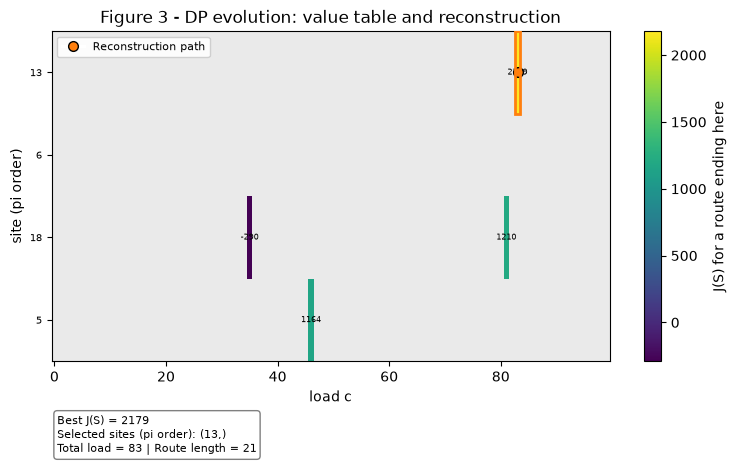

In [11]:
demo_sites = demo_subset_for_figure_3(pi_order)
demo_capacity = demo_capacity_for_figure_3(instance, demo_sites)
demo_solution, demo_dp = solve_dp(instance, capacity=demo_capacity, pi_order=demo_sites, distance=distance)

fig3 = plot_dp_table(instance, demo_dp, demo_sites, demo_solution)
plt.show()

## 8. Complexity and measurements (Part F)

Full derivation (state count, time/space/recursion-depth/temporary-copies/worst-case for both
algorithms, the pseudo-polynomial remark, and why this DP's recurrence cannot be reduced to an
`O(C)` vector) is in `docs/analise_complexidade.md`. Below: the same measurements it reports,
regenerated live.

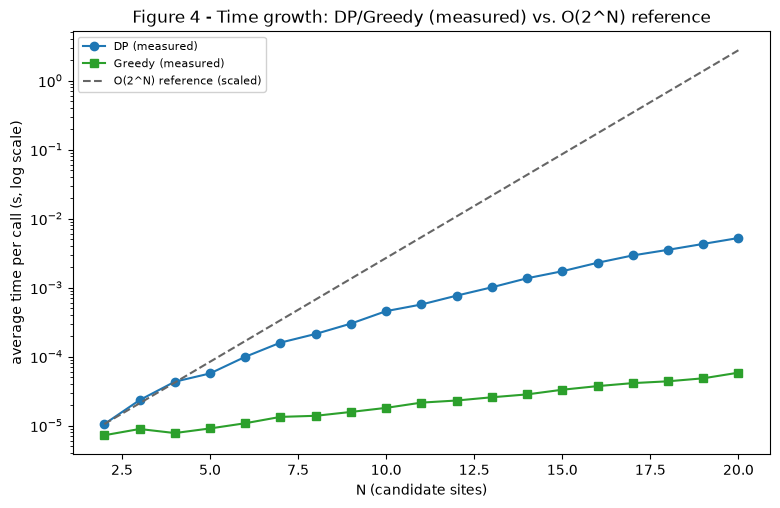

At N=20, C=581: DP peak memory ~ 316.3 KB, Greedy peak memory ~ 5.2 KB
Big O describes growth, not seconds (Lesson 11): these numbers are evidence for the shape of the curve above, not a substitute for the O(N^2*C) / O(N^3) bounds derived in docs/analise_complexidade.md.


In [12]:
dp_points = sweep_dp_time_by_n(instance, pi_order, distance)
greedy_points = sweep_greedy_time_by_n(instance, pi_order, distance)
n_values = [n for n, _ in dp_points]
dp_times = [t for _, t in dp_points]
greedy_times = [t for _, t in greedy_points]

fig4 = plot_time_growth(n_values, dp_times, greedy_times)
plt.show()

dp_memory = peak_memory_bytes(solve_dp, (instance, capacity, pi_order, distance))
greedy_memory = peak_memory_bytes(solve_greedy, (instance, capacity, pi_order, distance))
print(f"At N={len(pi_order)}, C={capacity}: DP peak memory ~ {dp_memory / 1024:.1f} KB, "
      f"Greedy peak memory ~ {greedy_memory / 1024:.1f} KB")
print("Big O describes growth, not seconds (Lesson 11): these numbers are evidence for the "
      "shape of the curve above, not a substitute for the O(N^2*C) / O(N^3) bounds derived in "
      "docs/analise_complexidade.md.")

## 9. Live input changes (for the defense)

Every input the professor might change live — capacity, `lambda_price`, a site's `priority` or
demand, a road's `distance`, or which roads are `available` — is a plain parameter or a CSV
value, not something hardcoded inside the solvers. Two examples below; re-run from Section 3
after editing `data/problema1.csv` / `problema1_edges.csv` to demonstrate a changed connection
or weight.

In [13]:
# Example 1: half the default capacity.
half_capacity = capacity // 2
half_solution, _ = solve_dp(instance, capacity=half_capacity, pi_order=pi_order, distance=distance)
print(f"Capacity {half_capacity} (half of {capacity}): "
      f"{len(half_solution.selected_sites)} sites, J(S) = {half_solution.objective_value}")

# Example 2: a different lambda (distance matters more).
alt_lambda = LAMBDA_DISTANCE_PRICE * 2
alt_solution, _ = solve_dp(instance, capacity=capacity, pi_order=pi_order, distance=distance, lambda_price=alt_lambda)
print(f"lambda_price={alt_lambda} (2x default): "
      f"{len(alt_solution.selected_sites)} sites, J(S) = {alt_solution.objective_value}")

Capacity 290 (half of 581): 3 sites, J(S) = 6278
lambda_price=42 (2x default): 6 sites, J(S) = 6363


## 10. Summary

- **Part A**: 21-node graph (1 depot + 20 sites), 38 available roads, 8 blocked roads, generated
  deterministically from `SEED = 1` and loaded back with full validation.
- **Part B**: Greedy (`solve_greedy`) picks the best marginal-benefit-density site each round.
- **Part C**: DP (`solve_dp`) finds the capacity-constrained optimum by dynamic programming over
  `(last site, load)` states, with full reconstruction.
- **Part D**: DP is never worse than Greedy under the shared objective `J(S)`; a hand-built
  counterexample and the real seed-1 dataset both show Greedy strictly losing to DP.
- **Part E**: four figures — the service network, the DP service plan, the DP evolution table,
  and the measured-time-vs-`O(2^N)` growth comparison.
- **Part F**: Greedy is `O(N^3)` time / `O(N)` memory; DP is `O(N^2*C)` time / `O(N*C)` memory
  (pseudo-polynomial in `C`); both confirmed against real measurements above.